# Panel composition — arch3 (production, 231 founders)

Descriptive distributions of the current production panel: variant classes
(SNP / indel / SV), SV size spectrum, allele-frequency spectrum, missingness,
per-founder carrier counts (cactus long-read vs PanGenie short-read cohorts),
and genomic density. All numbers computed directly from
`panel/arch3/chr{1..5}/var_pa_231_arch3_chr{1..5}.{var_pa,var_called,meta}.npz`
and should reconcile with `results/panel_stats/PANEL_STATS.md`
(`scripts/panel_stats_for_paper.py`) -- that report has the authoritative tables;
this notebook is the plotted companion.

**Supersedes** `preprocess_qc/notebooks/production_vcf_stats.ipynb`, which
answered this on the pre-arch3 `founders_231_chr.vcf.gz` panel and is now
archived (`archive/preprocess_qc/`).

SV cutoff: length change `|alt_len - ref_len| > 50bp` (matches PANEL_STATS and
`build_sv_snp_ld.py`).


In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJ = "/global/scratch/users/tbellg/kmate"
CHROMS = [1, 2, 3, 4, 5]
NF = 231

PLOTDIR = f"{PROJ}/analysis/grenenet_gea/notebooks/plots"
os.makedirs(PLOTDIR, exist_ok=True)

# --- style: seaborn theme. Project convention: no chart titles / subplot titles
# anywhere -- markdown section headers + axis labels carry context instead. ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110})

CLASS_ORDER = ["SNP", "indel", "SV"]
KIND_ORDER = ["INS", "DEL", "MNP"]
# One coherent palette for the whole notebook: every semantic entity (class,
# cohort, indel/SV direction) gets its own fixed, non-overlapping color, used
# identically in every chart it appears in.
_pal = sns.color_palette("deep", 10)
CLASS_COLOR = {"SNP": _pal[0], "indel": _pal[2], "SV": _pal[3]}         # blue, green, red
# Cohort naming: "long-read" (cactus assemblies) vs "short-read" (PanGenie-genotyped)
# -- names the sequencing/assembly method, which is what actually drives the
# differences seen below, rather than the tool names.
COL_LONGREAD, COL_SHORTREAD = _pal[1], _pal[4]                          # orange, purple
KIND_COLOR = {"INS": _pal[9], "DEL": _pal[5], "MNP": _pal[6]}           # cyan, brown, pink

longread_set = set(l.strip() for l in
    open(f"{PROJ}/panel/pangenie_genotyping/data/cactus_80_ecotypes.txt"))

rec_chrom, rec_pos, rec_cls, rec_kind, rec_svsize, rec_ac, rec_an = [], [], [], [], [], [], []
rec_miss_lr, rec_miss_sr = [], []           # per-record missing count, long-read / short-read side
n_alt_tot = np.zeros(NF, dtype=np.int64)         # per-founder ALT-carrier record count (all classes)
n_called_tot = np.zeros(NF, dtype=np.int64)      # per-founder called-genotype record count
n_snp_alt_tot = np.zeros(NF, dtype=np.int64)     # per-founder SNP-only ALT-carrier count
n_indel_alt_tot = np.zeros(NF, dtype=np.int64)   # per-founder indel-only ALT-carrier count
n_sv_alt_tot = np.zeros(NF, dtype=np.int64)      # per-founder SV-only ALT-carrier count
n_alt_mac2 = np.zeros(NF, dtype=np.int64)        # same 4, restricted to MAC>=2 records
n_snp_alt_mac2 = np.zeros(NF, dtype=np.int64)
n_indel_alt_mac2 = np.zeros(NF, dtype=np.int64)
n_sv_alt_mac2 = np.zeros(NF, dtype=np.int64)
founders = None
is_longread = None      # bool array, founder order, set once founders is known
N_LR = N_SR = None
N_total = 0

for c in CHROMS:
    cl, Cl = f"chr{c}", f"Chr{c}"
    m = np.load(f"{PROJ}/panel/arch3/{cl}/var_pa_231_arch3_{cl}.meta.npz", allow_pickle=True)
    pos = m["pos"]; rl = m["ref_len"].astype(np.int64); al = m["alt_len"].astype(np.int64)
    if founders is None:
        founders = [str(x) for x in m["founders"]]
        is_longread = np.array([f in longread_set for f in founders])
        N_LR, N_SR = int(is_longread.sum()), int((~is_longread).sum())
    N = len(pos)
    ldiff = np.abs(al - rl)
    snp = (rl == 1) & (al == 1)
    sv  = ldiff > 50
    indel = (~snp) & (~sv)
    cls = np.where(snp, "SNP", np.where(sv, "SV", "indel"))
    ins  = al > rl
    dele = rl > al
    mnp  = (rl == al) & (rl > 1)
    kind = np.where(snp, "SNP", np.where(ins, "INS", np.where(dele, "DEL", "MNP")))

    zp = np.load(f"{PROJ}/panel/arch3/{cl}/var_pa_231_arch3_{cl}.var_pa.npz", allow_pickle=False)
    zc = np.load(f"{PROJ}/panel/arch3/{cl}/var_pa_231_arch3_{cl}.var_called.npz", allow_pickle=False)
    ac = np.bincount(zp["indices"], minlength=N).astype(np.int32)
    an = np.bincount(zc["indices"], minlength=N).astype(np.int32)
    mac_keep = np.minimum(ac, an - ac) >= 2   # per-record MAC>=2 mask

    ip_p = zp["indptr"]; row_nnz_p = ip_p[1:] - ip_p[:-1]
    ip_c = zc["indptr"]; row_nnz_c = ip_c[1:] - ip_c[:-1]
    n_alt_tot += row_nnz_p; n_called_tot += row_nnz_c

    row = np.repeat(np.arange(NF), row_nnz_p)
    idx = zp["indices"]
    snp_col, indel_col, sv_col = snp[idx], indel[idx], sv[idx]
    mac2_col = mac_keep[idx]
    n_snp_alt_tot   += np.bincount(row[snp_col], minlength=NF)
    n_indel_alt_tot += np.bincount(row[indel_col], minlength=NF)
    n_sv_alt_tot    += np.bincount(row[sv_col], minlength=NF)
    n_alt_mac2       += np.bincount(row[mac2_col], minlength=NF)
    n_snp_alt_mac2   += np.bincount(row[snp_col & mac2_col], minlength=NF)
    n_indel_alt_mac2 += np.bincount(row[indel_col & mac2_col], minlength=NF)
    n_sv_alt_mac2    += np.bincount(row[sv_col & mac2_col], minlength=NF)

    # per-record called count, split by cohort (row-subset column tally) --
    # to check which side (long-read vs short-read) drives per-record missingness.
    row_c = np.repeat(np.arange(NF), row_nnz_c)
    idx_c = zc["indices"]
    lr_row_c = is_longread[row_c]
    n_called_lr = np.bincount(idx_c[lr_row_c], minlength=N)
    n_called_sr = np.bincount(idx_c[~lr_row_c], minlength=N)
    rec_miss_lr.append(N_LR - n_called_lr); rec_miss_sr.append(N_SR - n_called_sr)

    rec_chrom.append(np.full(N, Cl)); rec_pos.append(pos); rec_cls.append(cls); rec_kind.append(kind)
    rec_svsize.append(np.where(sv, ldiff, 0)); rec_ac.append(ac); rec_an.append(an)
    N_total += N
    print(f"  {Cl}: {N:,} records loaded")

rec = pd.DataFrame({
    "chrom": np.concatenate(rec_chrom), "pos": np.concatenate(rec_pos),
    "cls": np.concatenate(rec_cls), "kind": np.concatenate(rec_kind),
    "sv_size": np.concatenate(rec_svsize),
    "ac": np.concatenate(rec_ac), "an": np.concatenate(rec_an),
    "n_miss_lr": np.concatenate(rec_miss_lr), "n_miss_sr": np.concatenate(rec_miss_sr),
})
rec["maf"] = np.where(rec.an > 0, np.minimum(rec.ac, rec.an - rec.ac) / rec.an.replace(0, 1), np.nan)

cohort = np.array(["long-read" if lr else "short-read" for lr in is_longread])
founder = pd.DataFrame({
    "founder": founders, "cohort": cohort,
    "n_alt": n_alt_tot, "n_called": n_called_tot, "n_missing": N_total - n_called_tot,
    "n_snp_alt": n_snp_alt_tot, "n_indel_alt": n_indel_alt_tot, "n_sv_alt": n_sv_alt_tot,
    "n_alt_mac2": n_alt_mac2, "n_snp_alt_mac2": n_snp_alt_mac2,
    "n_indel_alt_mac2": n_indel_alt_mac2, "n_sv_alt_mac2": n_sv_alt_mac2,
})

print(f"\n{N_total:,} records genome-wide, {len(founder):,} founders "
      f"({N_LR} long-read + {N_SR} short-read)")
print(rec.cls.value_counts().rename("n"))

  Chr1: 2,154,423 records loaded


  Chr2: 1,463,385 records loaded


  Chr3: 1,592,677 records loaded


  Chr4: 1,368,120 records loaded


  Chr5: 1,911,041 records loaded



8,489,646 records genome-wide, 231 founders (80 long-read + 151 short-read)
cls
SNP      6237063
indel    2026115
SV        226468
Name: n, dtype: int64


## 1. Variant class composition

genome-wide: {'SNP': 6237063, 'indel': 2026115, 'SV': 226468}
(cross-check vs results/panel_stats/PANEL_STATS.md §2: SNP 6,237,063 / indel 2,026,115 / SV 226,468)


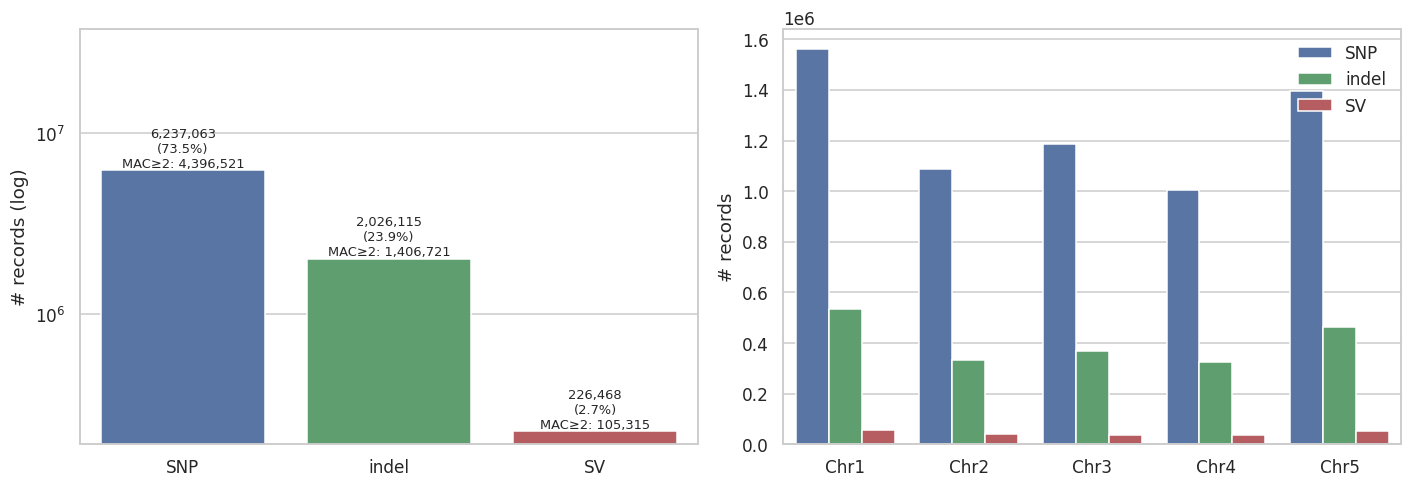

In [2]:
# 1. Variant class composition (SNP / indel / SV), genome-wide + per chromosome
counts = rec.cls.value_counts().reindex(CLASS_ORDER)
print("genome-wide:", dict(counts))
print("(cross-check vs results/panel_stats/PANEL_STATS.md §2: "
      "SNP 6,237,063 / indel 2,026,115 / SV 226,468)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
comp_df = counts.rename_axis("cls").reset_index(name="n")
sns.barplot(data=comp_df, x="cls", y="n", hue="cls", order=CLASS_ORDER,
            palette=CLASS_COLOR, legend=False, ax=ax)
ax.set_yscale("log"); ax.set_ylabel("# records (log)"); ax.set_xlabel("")
ax.set_ylim(top=counts.values.max() * 6)   # headroom so the top label clears the frame
mac2_counts = {c: int((np.minimum(rec.loc[rec.cls == c, "ac"], rec.loc[rec.cls == c, "an"] - rec.loc[rec.cls == c, "ac"]) >= 2).sum())
               for c in CLASS_ORDER}
for i, cl_ in enumerate(CLASS_ORDER):
    n = counts[cl_]
    ax.annotate(f"{n:,}\n({100*n/N_total:.1f}%)\nMAC≥2: {mac2_counts[cl_]:,}",
                (i, n), ha="center", va="bottom", fontsize=8.5)

ax = axes[1]
pc = rec.groupby(["chrom", "cls"]).size().rename("n").reset_index()
pc["chrom"] = pd.Categorical(pc["chrom"], [f"Chr{c}" for c in CHROMS], ordered=True)
sns.barplot(data=pc, x="chrom", y="n", hue="cls", hue_order=CLASS_ORDER, palette=CLASS_COLOR, ax=ax)
ax.set_ylabel("# records"); ax.set_xlabel("")
ax.legend(frameon=False, title=None, loc="upper right")

plt.tight_layout()
fig.savefig(f"{PLOTDIR}/01_variant_class_composition.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Insertion vs deletion (indels + SVs)

cls    kind
indel  INS     715094
       DEL     899326
       MNP     411695
SV     INS     172220
       DEL      54248
       MNP          0
Name: n, dtype: int64
(cross-check vs results/panel_stats/PANEL_STATS.md §2 INS/DEL/MNP genome-wide: 887,314 / 953,574 / 411,695)


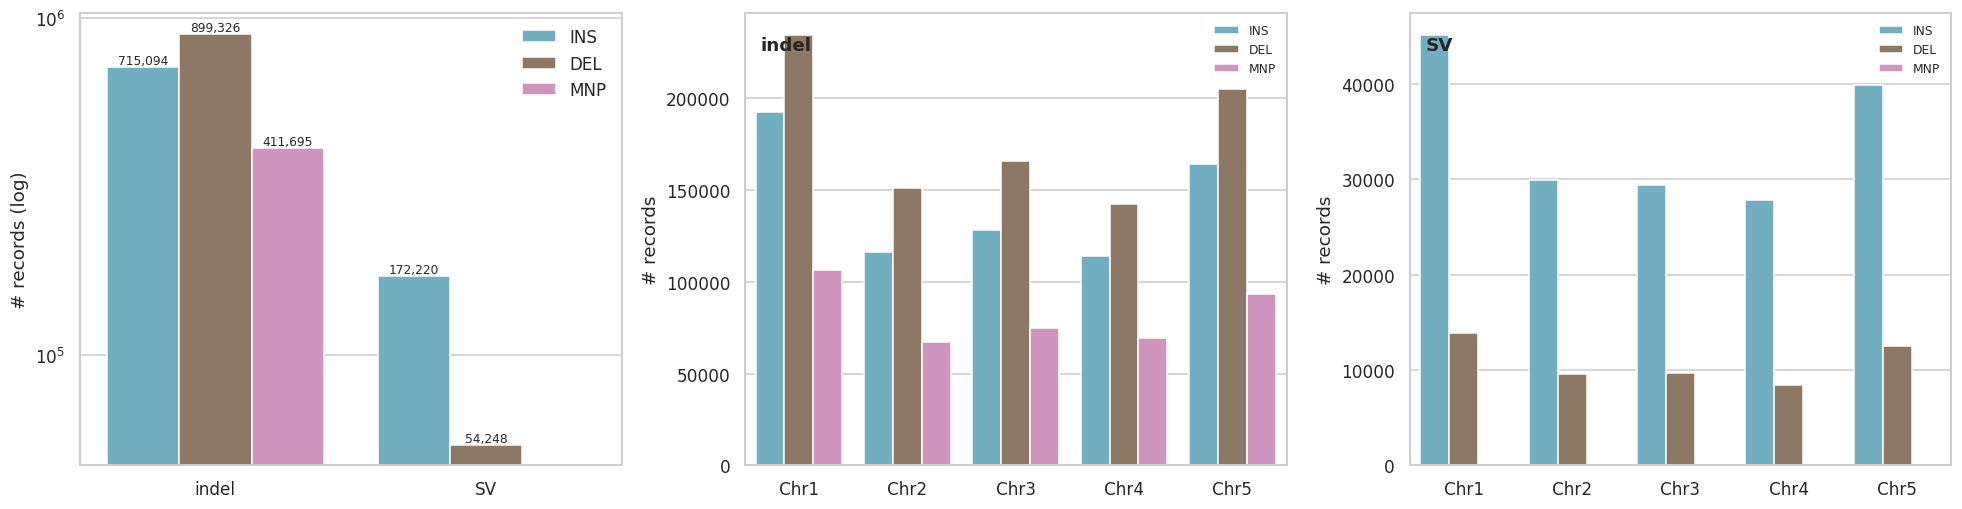

In [3]:
# 2. Insertion vs deletion, indels and SVs (SNPs have no direction, excluded).
# Same style as §1: genome-wide summary + per-chromosome breakdown.
kind_counts = rec[rec.cls.isin(["indel", "SV"])].groupby(["cls", "kind"]).size()
kind_counts = kind_counts.reindex(
    pd.MultiIndex.from_product([["indel", "SV"], KIND_ORDER], names=["cls", "kind"]), fill_value=0)
print(kind_counts.rename("n"))
print("(cross-check vs results/panel_stats/PANEL_STATS.md §2 INS/DEL/MNP genome-wide: "
      "887,314 / 953,574 / 411,695)")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

ax = axes[0]
kd_df = kind_counts.rename("n").reset_index()
sns.barplot(data=kd_df, x="cls", y="n", hue="kind", order=["indel", "SV"],
            hue_order=KIND_ORDER, palette=KIND_COLOR, ax=ax)
ax.set_yscale("log"); ax.set_xlabel(""); ax.set_ylabel("# records (log)")
ax.legend(frameon=False, title=None)
for container, k in zip(ax.containers, KIND_ORDER):
    for bar, cl_ in zip(container, ["indel", "SV"]):
        n = int(kind_counts[(cl_, k)])
        ax.annotate(f"{n:,}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha="center", va="bottom", fontsize=8)

for ax, cl_ in zip(axes[1:], ["indel", "SV"]):
    pc = rec[rec.cls == cl_].groupby(["chrom", "kind"]).size().rename("n").reset_index()
    pc["chrom"] = pd.Categorical(pc["chrom"], [f"Chr{c}" for c in CHROMS], ordered=True)
    sns.barplot(data=pc, x="chrom", y="n", hue="kind", hue_order=KIND_ORDER, palette=KIND_COLOR, ax=ax)
    ax.set_ylabel("# records"); ax.set_xlabel("")
    ax.annotate(cl_, xy=(0.03, 0.95), xycoords="axes fraction", ha="left", va="top", fontweight="bold")
    ax.legend(frameon=False, title=None, fontsize=8)
plt.tight_layout()
fig.savefig(f"{PLOTDIR}/02_insertion_deletion.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. SV size spectrum

sv_size
50-100bp      30620
100bp-1kb    108481
1kb-10kb      77757
>10kb          9610
Name: n, dtype: int64
largest SV: 291,065 bp


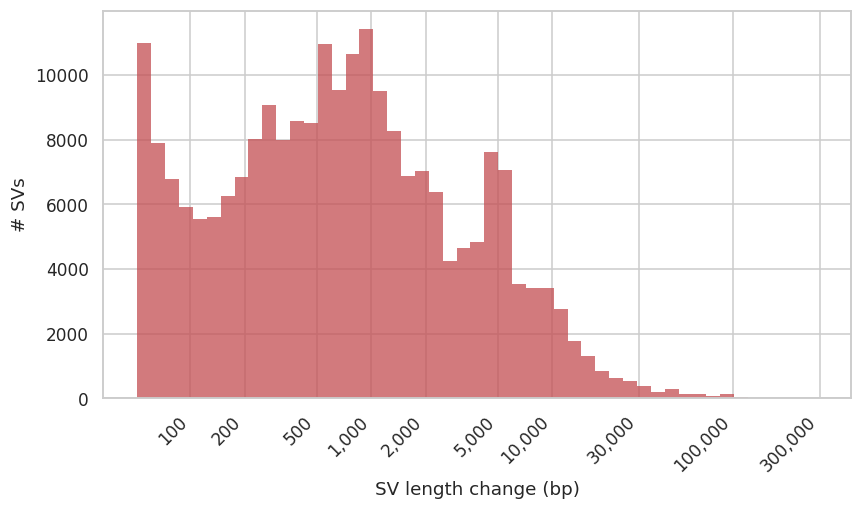

In [4]:
# 3. SV size spectrum (length change, bp) -- continuous distribution only;
# the binned bar version was redundant with this.
sv = rec[rec.cls == "SV"]
bin_edges = [50, 100, 1000, 10000, sv.sv_size.max() + 1]
bin_labels = ["50-100bp", "100bp-1kb", "1kb-10kb", ">10kb"]
sv_binned = pd.cut(sv.sv_size, bins=bin_edges, labels=bin_labels, right=True, include_lowest=True)
sv_counts = sv_binned.value_counts().reindex(bin_labels)
print(sv_counts.rename("n"))
print(f"largest SV: {int(sv.sv_size.max()):,} bp")

fig, ax = plt.subplots(figsize=(8, 4.8))
log_bins = np.logspace(np.log10(sv.sv_size.min()), np.log10(sv.sv_size.max()), 50)
sns.histplot(sv.sv_size, bins=log_bins, color=CLASS_COLOR["SV"], ax=ax)
ax.set_xscale("log")
ticks = [t for t in [50, 100, 200, 500, 1000, 2000, 5000, 10000, 30000, 100000, 300000]
         if sv.sv_size.min() <= t <= sv.sv_size.max() * 1.1]
ax.set_xticks(ticks); ax.set_xticklabels([f"{t:,}" for t in ticks], rotation=45, ha="right")
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("SV length change (bp)"); ax.set_ylabel("# SVs")
plt.tight_layout()
fig.savefig(f"{PLOTDIR}/03_sv_size_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Allele-frequency / MAC spectrum

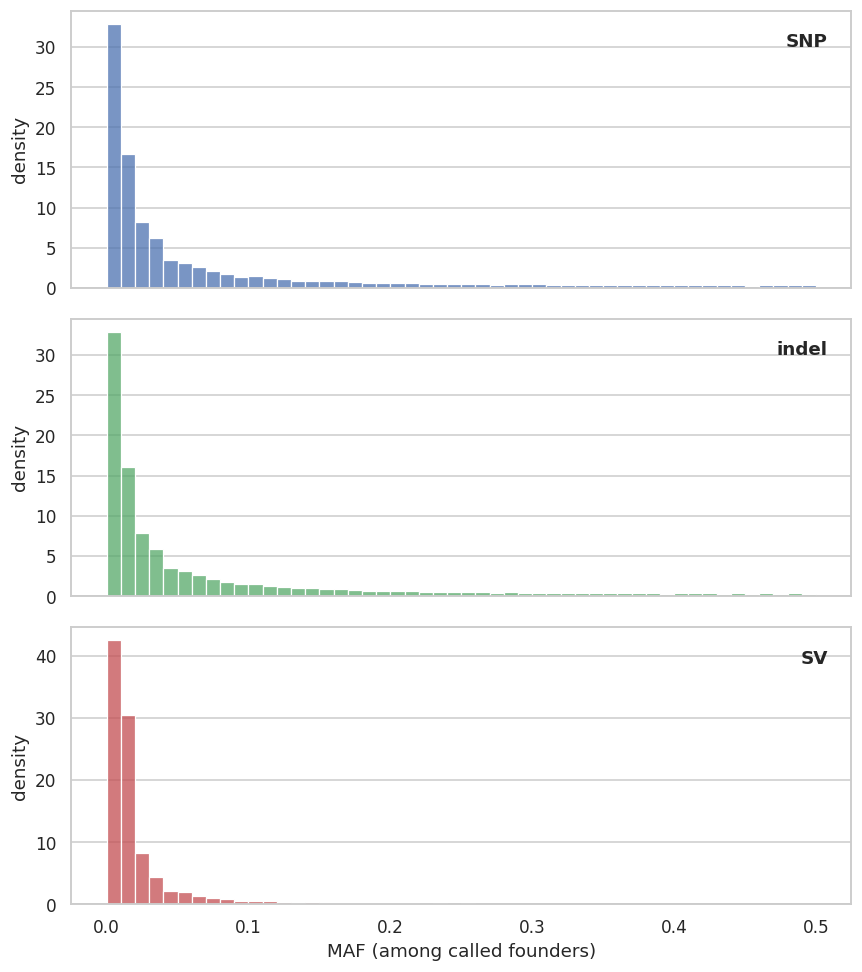

singletons (MAC=1) -- dropped by even the lightest MAC>=2 filter:


  SNP: 1,840,542 / 6,237,063 (29.5%)


  indel: 619,394 / 2,026,115 (30.6%)


  SV: 121,153 / 226,468 (53.5%)


MAC>=    2     5     10    20
class                        
SNP    70.5  46.1  32.3  21.1
indel  69.4  46.7  33.1  21.6
SV     46.5  20.1  10.5   5.5


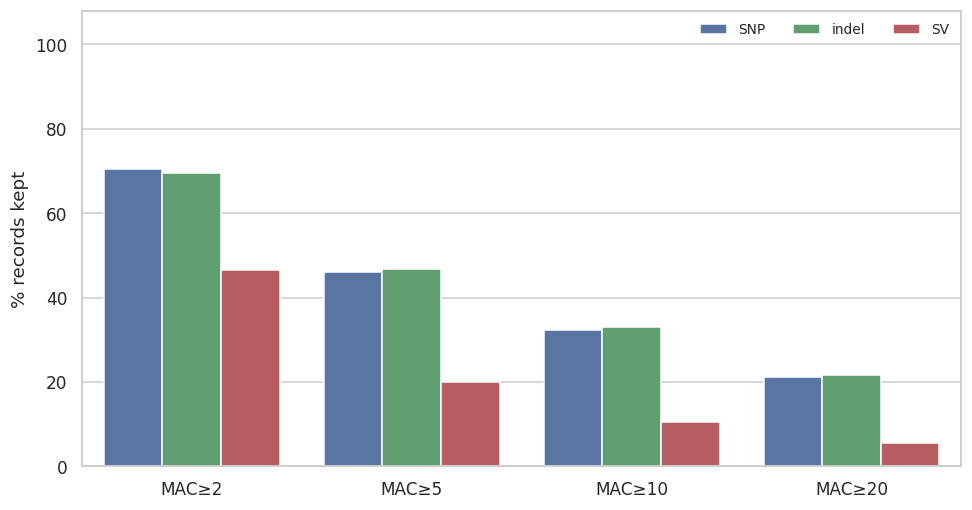

In [5]:
# 4. Allele-frequency / MAC spectrum, by class
# Small multiples stacked vertically (one row per class, shared x-axis) --
# overlaid on one axes was too hard to read given how differently-shaped
# the classes are.
fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
bins = np.linspace(0, 0.5, 51)
for ax, c in zip(axes, CLASS_ORDER):
    sns.histplot(rec.loc[rec.cls == c, "maf"].dropna(), bins=bins, color=CLASS_COLOR[c],
                 stat="density", ax=ax)
    ax.set_ylabel("density")
    ax.annotate(c, xy=(0.97, 0.92), xycoords="axes fraction", ha="right", va="top", fontweight="bold")
    ax.grid(axis="x", visible=False)
axes[-1].set_xlabel("MAF (among called founders)")
plt.tight_layout()
fig.savefig(f"{PLOTDIR}/04a_maf_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

# MAC survival: the panel is segregating-only by construction (0<AC<AN for every
# record), so MAC>=1 is trivially 100% for every class and shows nothing -- start
# at MAC>=2 instead. Singleton (MAC=1) share is the informative "floor" number.
print("singletons (MAC=1) -- dropped by even the lightest MAC>=2 filter:")
for c in CLASS_ORDER:
    sub = rec[rec.cls == c]
    mac = np.minimum(sub.ac, sub.an - sub.ac)
    n_single = int((mac == 1).sum())
    print(f"  {c}: {n_single:,} / {len(sub):,} ({100*n_single/len(sub):.1f}%)")

thresholds_mac = [2, 5, 10, 20]
rows = []
for c in CLASS_ORDER:
    sub = rec[rec.cls == c]
    mac = np.minimum(sub.ac, sub.an - sub.ac)
    for t in thresholds_mac:
        rows.append({"class": c, "MAC>=": t, "pct": 100*(mac >= t).mean()})
mac_df = pd.DataFrame(rows)
print(mac_df.pivot(index="class", columns="MAC>=", values="pct").reindex(CLASS_ORDER).round(1))

# Grouped by MAC threshold (the 3 main x-categories), SNP/indel/SV side by side within each.
fig, ax = plt.subplots(figsize=(9, 4.8))
mac_df["MAC_label"] = mac_df["MAC>="].map(lambda t: f"MAC≥{t}")
mac_order = [f"MAC≥{t}" for t in thresholds_mac]
sns.barplot(data=mac_df, x="MAC_label", y="pct", hue="class", order=mac_order,
            hue_order=CLASS_ORDER, palette=CLASS_COLOR, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("% records kept"); ax.set_ylim(0, 108)
ax.legend(frameon=False, title=None, loc="upper right", ncol=3, fontsize=9)
plt.tight_layout()
fig.savefig(f"{PLOTDIR}/04b_mac_survival.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Missingness

Overall genotype missing rate: 14.49%


       mean  median
cls                
SNP    32.1    10.0
indel  34.8    20.0
SV     60.0    41.0



spike (140-160 missing, n=752,938): median short-read-missing 151/151, median long-read-missing 2/80


rest of records (n=7,736,708): median short-read-missing 5/151, median long-read-missing 0/80


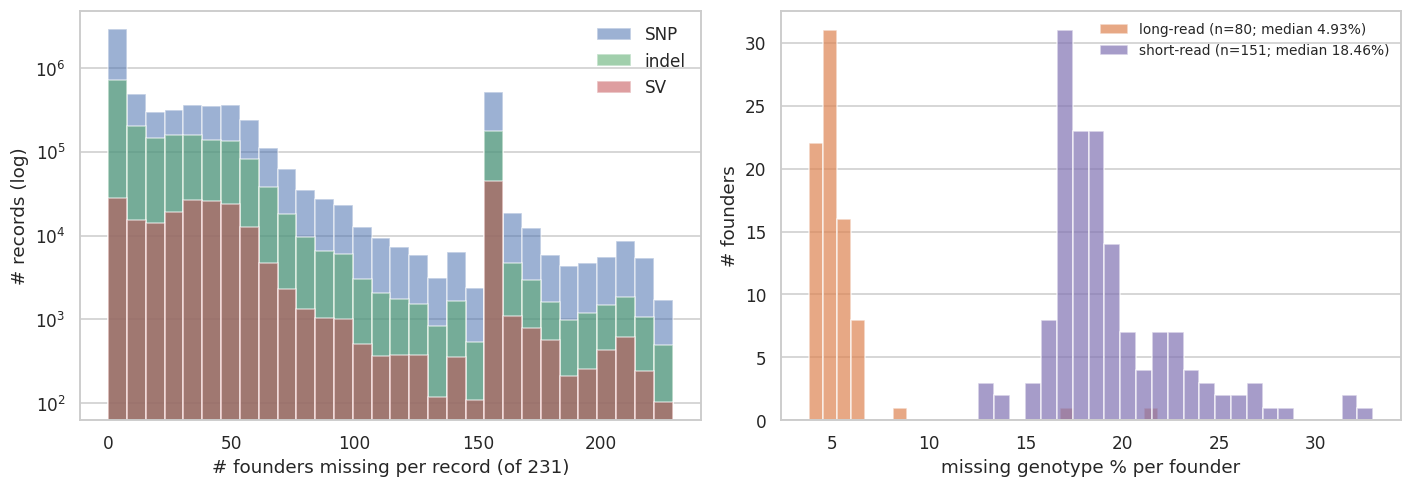

In [6]:
# 5. Missingness -- record-level (by class) and founder-level (by cohort)
rec["n_miss_founders"] = NF - rec.an   # raw count (of 231) rather than % -- more concrete
rec["miss_frac"] = rec.n_miss_founders / NF
print("Overall genotype missing rate:",
      f"{100*(1 - rec.an.sum()/(NF*N_total)):.2f}%")
print(rec.groupby("cls").n_miss_founders.agg(["mean", "median"]).reindex(CLASS_ORDER).round(1))

# Check the ~150-missing spike: is it records where the long-read (cactus) side
# is called but the short-read (PanGenie, n=151) side is essentially all missing?
spike = rec[(rec.n_miss_founders >= 140) & (rec.n_miss_founders <= 160)]
other = rec[(rec.n_miss_founders < 140) | (rec.n_miss_founders > 160)]
print(f"\nspike (140-160 missing, n={len(spike):,}): median short-read-missing "
      f"{int(spike.n_miss_sr.median())}/{N_SR}, median long-read-missing {int(spike.n_miss_lr.median())}/{N_LR}")
print(f"rest of records (n={len(other):,}): median short-read-missing "
      f"{int(other.n_miss_sr.median())}/{N_SR}, median long-read-missing {int(other.n_miss_lr.median())}/{N_LR}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
for c in CLASS_ORDER:
    ax.hist(rec.loc[rec.cls == c, "n_miss_founders"], bins=30, color=CLASS_COLOR[c],
             alpha=0.55, label=c)
ax.set_yscale("log"); ax.set_xlabel(f"# founders missing per record (of {NF})"); ax.set_ylabel("# records (log)")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)

ax = axes[1]
founder["missing_pct"] = 100 * founder.n_missing / N_total
for coh, col in [("long-read", COL_LONGREAD), ("short-read", COL_SHORTREAD)]:
    sub = founder[founder.cohort == coh]
    ax.hist(sub.missing_pct, bins=25, alpha=0.7, color=col,
            label=f"{coh} (n={len(sub)}; median {sub.missing_pct.median():.2f}%)")
ax.set_xlabel("missing genotype % per founder"); ax.set_ylabel("# founders")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", visible=False)
plt.tight_layout()
fig.savefig(f"{PLOTDIR}/05_missingness.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Per-founder carrier counts (long-read vs short-read)

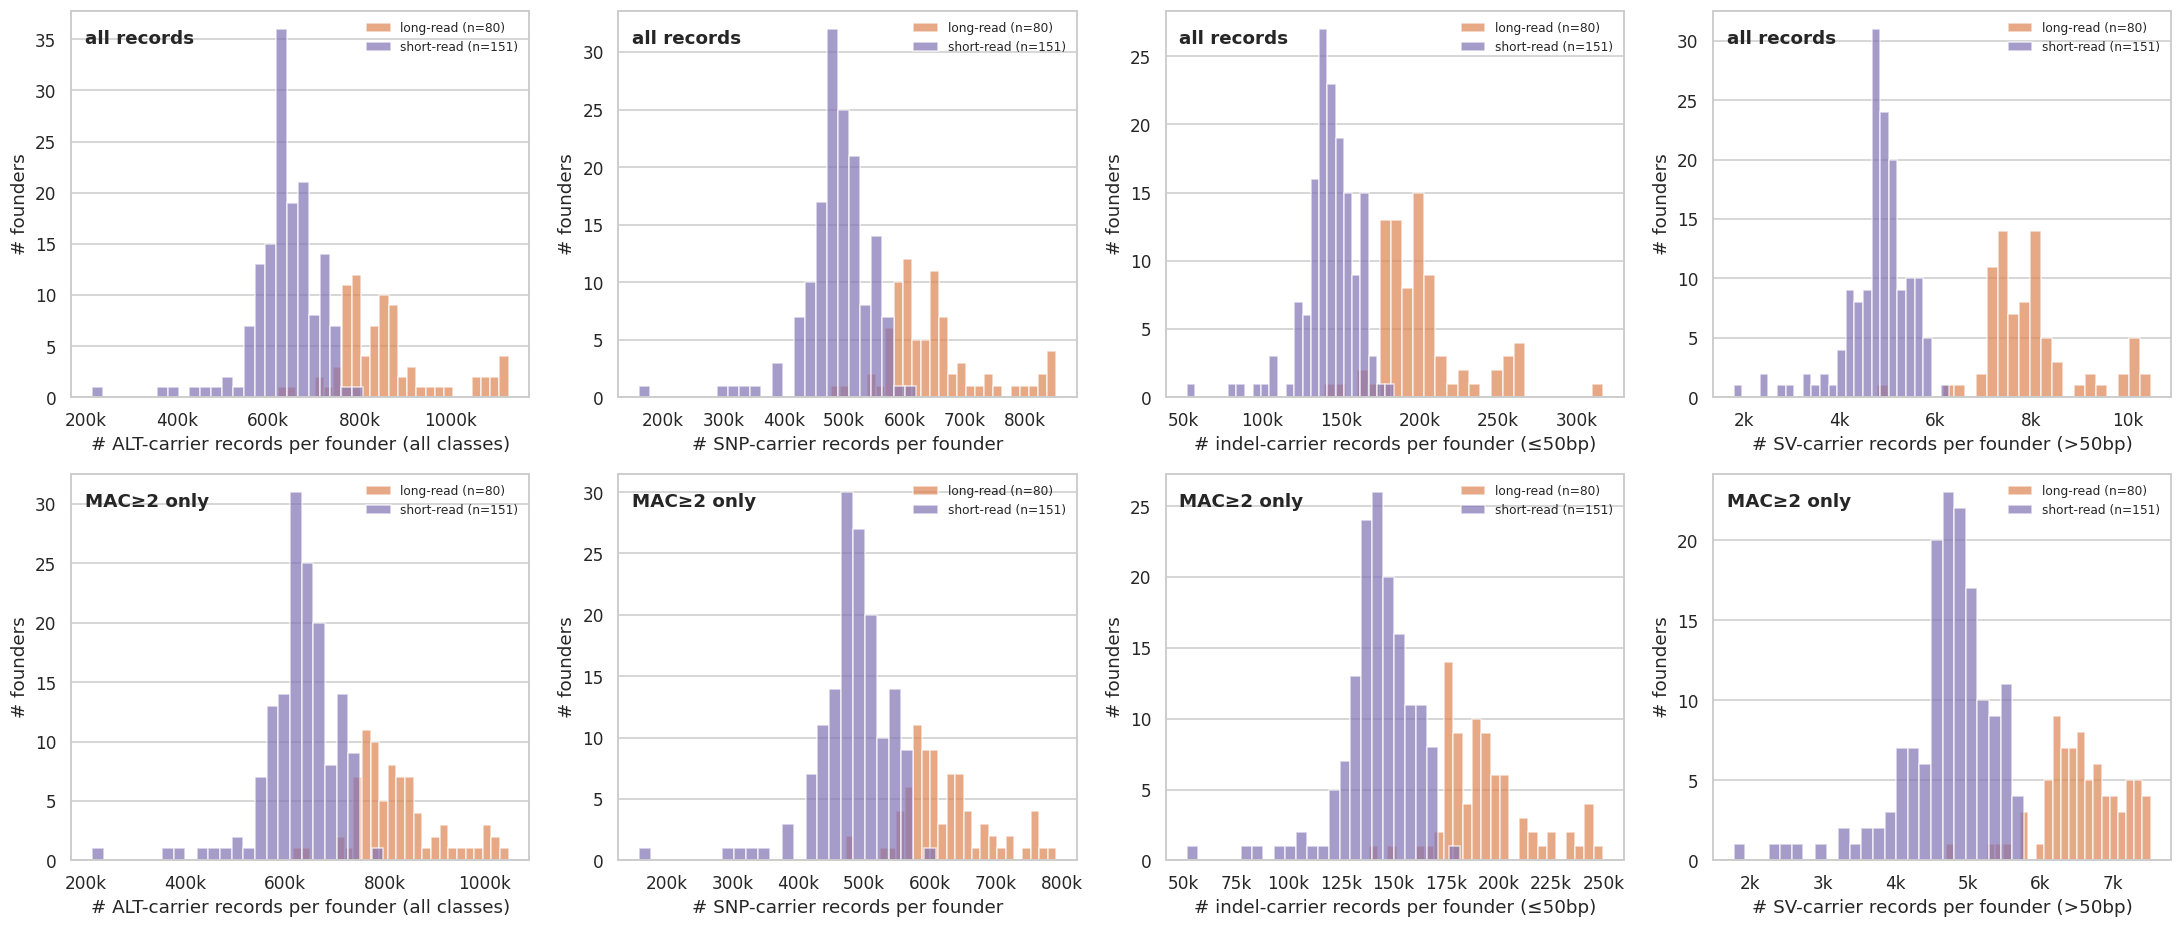

long-read (n=80): SNP 630,606 (MAC≥2: 610,349)  | indel 197,240 (MAC≥2: 190,330)  | SV 7,830 (MAC≥2: 6,542)  | all 837,285 (MAC≥2: 806,884)
short-read (n=151): SNP 491,653 (MAC≥2: 485,446)  | indel 144,079 (MAC≥2: 143,077)  | SV 4,887 (MAC≥2: 4,796)  | all 640,147 (MAC≥2: 633,053)


In [7]:
# 6. Per-founder carrier counts, long-read vs short-read cohort, one column per
# class (all classes, SNP, indel, SV). Top row: all records. Bottom row: MAC>=2
# only (singletons dropped) -- checks whether the long-read/short-read split is
# a singleton artifact or holds up.
def _kfmt(x, pos):
    return f"{x/1000:.0f}k" if abs(x) >= 1000 else f"{x:.0f}"

fig, axes = plt.subplots(2, 4, figsize=(20, 8.6))
panels = [("n_alt", "n_alt_mac2", "# ALT-carrier records per founder (all classes)"),
          ("n_snp_alt", "n_snp_alt_mac2", "# SNP-carrier records per founder"),
          ("n_indel_alt", "n_indel_alt_mac2", "# indel-carrier records per founder (≤50bp)"),
          ("n_sv_alt", "n_sv_alt_mac2", "# SV-carrier records per founder (>50bp)")]
for col_i, (col_all, col_mac2, xlabel) in enumerate(panels):
    for row_i, (col, tag) in enumerate([(col_all, "all records"), (col_mac2, "MAC≥2 only")]):
        ax = axes[row_i, col_i]
        for coh, color in [("long-read", COL_LONGREAD), ("short-read", COL_SHORTREAD)]:
            sub = founder[founder.cohort == coh]
            ax.hist(sub[col], bins=25, alpha=0.7, color=color, label=f"{coh} (n={len(sub)})")
        ax.set_xlabel(xlabel); ax.set_ylabel("# founders")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(_kfmt))
        ax.annotate(tag, xy=(0.03, 0.95), xycoords="axes fraction", ha="left", va="top", fontweight="bold")
        ax.legend(frameon=False, fontsize=8)
        ax.grid(axis="x", visible=False)
plt.tight_layout()
fig.savefig(f"{PLOTDIR}/06_founder_carrier_counts.png", dpi=150, bbox_inches="tight")
plt.show()

for coh in ["long-read", "short-read"]:
    sub = founder[founder.cohort == coh]
    print(f"{coh} (n={len(sub)}): "
          f"SNP {int(sub.n_snp_alt.median()):,} (MAC≥2: {int(sub.n_snp_alt_mac2.median()):,})  "
          f"| indel {int(sub.n_indel_alt.median()):,} (MAC≥2: {int(sub.n_indel_alt_mac2.median()):,})  "
          f"| SV {int(sub.n_sv_alt.median()):,} (MAC≥2: {int(sub.n_sv_alt_mac2.median()):,})  "
          f"| all {int(sub.n_alt.median()):,} (MAC≥2: {int(sub.n_alt_mac2.median()):,})")

## 7. Genomic density along chromosomes

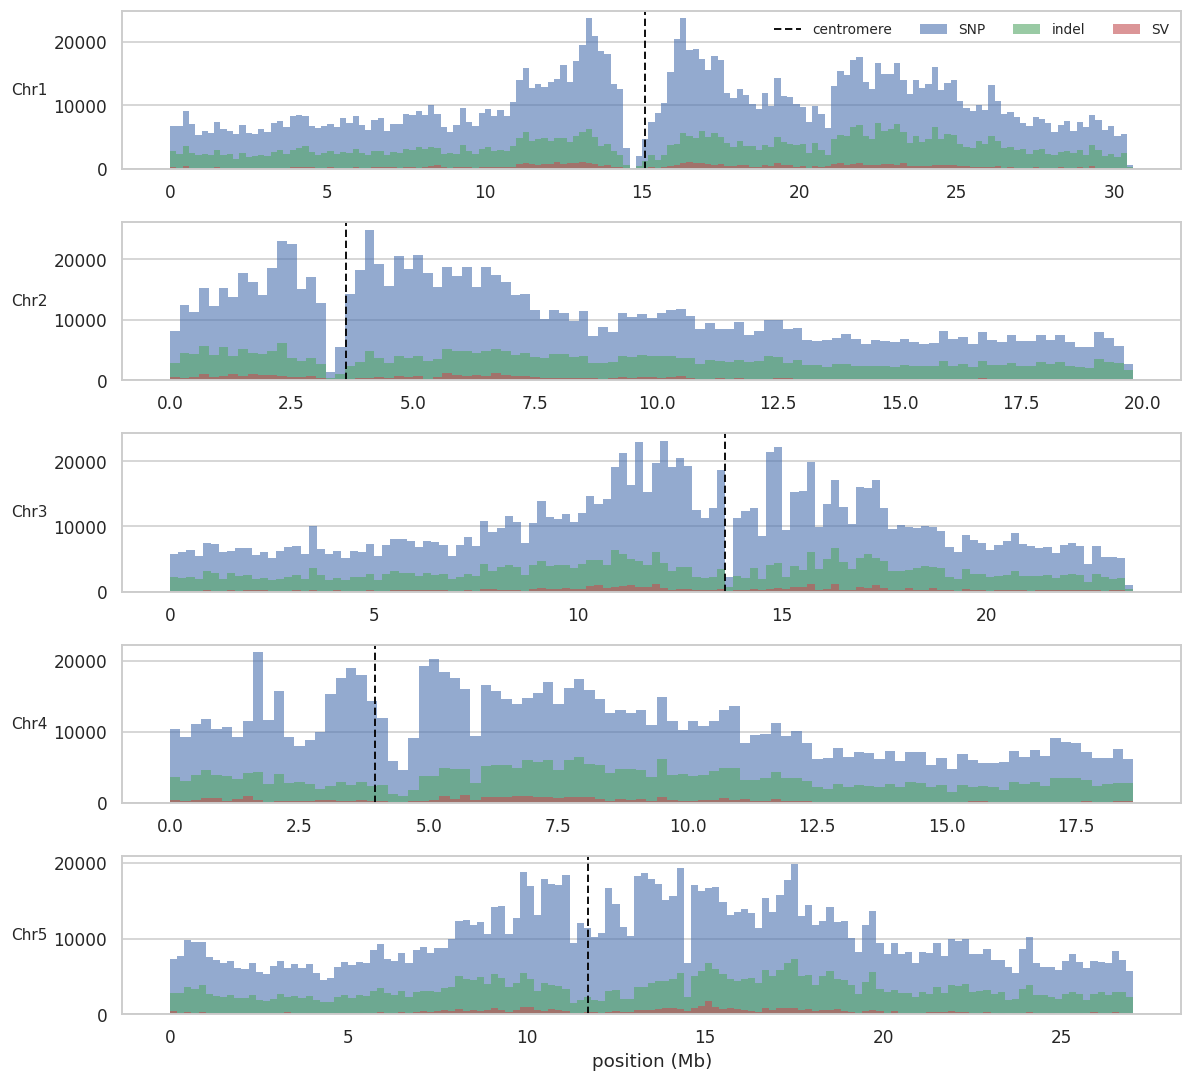

In [8]:
# 7. Genomic density -- variant density along each chromosome, by class.
# Overlaid (not stacked) with alpha: SVs are far rarer than SNP/indel, so stacking
# them on top buried their shape -- draw SNP/indel first, SV last (in front).
# Centromere midpoints (TAIR10), same values used elsewhere in this repo
# (analysis/grenenet_gea/_sv_hap_context.py CEN).
CENTROMERE_MB = {"Chr1": 15.086, "Chr2": 3.607, "Chr3": 13.588, "Chr4": 3.956, "Chr5": 11.726}

BIN_BP = 200_000
fig, axes = plt.subplots(len(CHROMS), 1, figsize=(11, 2.0*len(CHROMS)), sharex=False)
for ax, c in zip(axes, CHROMS):
    Cl = f"Chr{c}"
    sub = rec[rec.chrom == Cl]
    max_pos = sub.pos.max()
    bins = np.arange(0, max_pos + BIN_BP, BIN_BP)
    for cls in CLASS_ORDER:   # SNP, indel, SV -- SV plotted last so it renders on top
        h, _ = np.histogram(sub.loc[sub.cls == cls, "pos"], bins=bins)
        ax.bar(bins[:-1] / 1e6, h, width=BIN_BP/1e6, color=CLASS_COLOR[cls], alpha=0.6,
               label=cls if c == CHROMS[0] else None, align="edge", linewidth=0)
    ax.axvline(CENTROMERE_MB[Cl], color="black", lw=1.2, ls=(0, (4, 2)),
               label="centromere" if c == CHROMS[0] else None)
    ax.set_ylabel(Cl, rotation=0, ha="right", va="center", fontsize=10)
    ax.grid(axis="x", visible=False)
axes[-1].set_xlabel("position (Mb)")
axes[0].legend(frameon=False, loc="upper right", ncol=4, fontsize=9)
plt.tight_layout()
fig.savefig(f"{PLOTDIR}/07_genomic_density.png", dpi=150, bbox_inches="tight")
plt.show()

## Takeaways

- **Composition** (genome-wide, 8,489,646 records): 73.5% SNP, 23.9% indel
  (&le;50bp), 2.7% SV (&gt;50bp) &mdash; matches `results/panel_stats/PANEL_STATS.md` §2
  exactly.
- **Insertion vs deletion** (indels + SVs; SNPs have no direction): indels are
  deletion-leaning (899,326 DEL vs 715,094 INS vs 411,695 MNP), but **SVs are
  strongly insertion-biased** (172,220 INS vs only 54,248 DEL, ~76% insertions,
  0 MNP by definition of the &gt;50bp length-change cutoff).
- **SV size spectrum** is dominated by the 100bp-1kb bin; the largest SV is
  ~291kb. Consistent across chromosomes.
- **MAF spectrum** is rare-variant-heavy across all classes (median ALT
  frequency ~0.02 genome-wide, per `PANEL_STATS.md` §4). **SVs are singletons
  (MAC=1) far more often than SNPs/indels** &mdash; 53.5% of SVs vs ~30% of
  SNPs/indels &mdash; so an MAC&ge;2 floor removes a majority-sized slice of the SV
  catalog specifically; MAC&ge;1 is not shown since the panel is
  segregating-only by construction (trivially 100%).
- **Missingness**: the per-record panel (by class) shows a distinct secondary
  spike around ~151 founders missing. **Confirmed directly** (printed check in
  §5): records in that spike have a median of **151/151 short-read founders
  missing and only 2/80 long-read founders missing** &mdash; i.e. the entire
  short-read/PanGenie cohort is uncalled there and only the long-read/cactus
  side resolves. Per-founder missingness is far lower and tighter in long-read
  founders (median 4.9%) than short-read founders (median 18.5%) &mdash; expected,
  since PanGenie SV/indel genotyping from short reads is intrinsically harder
  than long-read assembly-based calling.
- **SV-carrier counts per founder differ by cohort and survive an MAC&ge;2
  filter** (long-read median 7,830 &rarr; 6,542 after MAC&ge;2; short-read 4,887
  &rarr; 4,796) &mdash; long-read founders lose noticeably more of their SV-carrier
  count to the singleton filter than short-read founders do, consistent with
  long-read (cactus) assemblies realizing more private/singleton variation
  (`BACKGROUND.md` known-limitations #2, `old_docs/BALANCING_KMERS.md`). The
  cohort gap is not merely a singleton artifact.
- **Genomic density**: variant density (all classes) tracks recombination-poor
  pericentromeric regions dropping out, consistent with the known centromere
  alignment dead zones (`BACKGROUND.md` known-limitations #6).
